# Multires 2K — noisy training + trace L1 loss (λ search)

**Sections:** 1 λ train · 2 λ plots · 3 SNR sweeps · **4 example @ 5 dB** · **5 example @ 0 dB** (scroll to bottom)

**Protocol**
- Train **Multires 2K** on **noisy traces** (SNR uniform **5–30 dB**).
- Loss: `L1_pulse + λ · (L1_trace_sum / trace_scale)` (trace vs. **clean** reference).
- Val: **200** pulses @ **15 dB**; early stopping on val pulse L1.
- **5** λ values in **[0, 3]**; pick λ* = argmin best val L1.
- Test SNR sweep (−10…30 dB, **512** pulses) vs. existing **Multires 60K** and **Multires 2K** (no trace loss).

In [2]:
import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

SRC = Path.cwd()
if not (SRC / "train.py").exists():
    SRC = SRC.parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from evaluate_cnn import load_cnn_sweep, plot_metric_curves
from pulse_metrics import snr_db_to_equivalent_n_pulses

SEED = 0
N_TRAIN = 2048
N_VAL = 200
N_TEST = 512
TRAIN_SNR_DB_RANGE = (5.0, 30.0)
VAL_SNR_DB = 15.0
LAMBDA_GRID = np.linspace(0.0, 3.0, 5)
MAX_EPOCHS = 200
PATIENCE = 25
SNR_SWEEP_DB = np.arange(-10.0, 31.0, 5.0)

RESULTS_NPZ = SRC / "checkpoints/benchmark/multires_2k_noisy_trace_lambda.npz"
META_JSON = SRC / "checkpoints/benchmark/multires_2k_noisy_trace_lambda_meta.json"
CKPT_DIR = SRC / "checkpoints/benchmark/multires_2k_noisy_trace_lambda"
OPT_CKPT = SRC / "checkpoints/benchmark/multires_2k_noisy_trace_lambda_opt.pt"
PHYS_SWEEP = SRC / "checkpoints/benchmark/multires_2k_noisy_trace_lambda_cnn_sweep.npz"

MULTIRES_60K_SWEEP = SRC / "checkpoints/large_60k_multires_50ep_cnn_sweep.npz"
MULTIRES_2K_SWEEP = SRC / "checkpoints/large_2k_multires_50ep_cnn_sweep.npz"

RUN_TRAINING = True  # set False to only load/plot existing results
FORCE_RETRAIN = False

## 1. Train λ grid + SNR sweep (optimal λ)

In [3]:
script = SRC / "scripts/run_multires_2k_noisy_trace_lambda.py"
cmd = [
    sys.executable,
    str(script),
    "--seed", str(SEED),
    "--n-train", str(N_TRAIN),
    "--n-val", str(N_VAL),
    "--n-test", str(N_TEST),
    "--max-epochs", str(MAX_EPOCHS),
    "--patience", str(PATIENCE),
    "--train-snr-min", str(TRAIN_SNR_DB_RANGE[0]),
    "--train-snr-max", str(TRAIN_SNR_DB_RANGE[1]),
    "--val-snr-db", str(VAL_SNR_DB),
    "--lambda-min", "0",
    "--lambda-max", "3",
    "--lambda-steps", "5",
]
if FORCE_RETRAIN:
    cmd.append("--force")
elif RESULTS_NPZ.exists():
    cmd.append("--resume")

if RUN_TRAINING:
    print("Running:", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=str(SRC))
    if proc.returncode != 0:
        raise RuntimeError(f"training script failed (exit {proc.returncode})")
else:
    print("RUN_TRAINING=False — loading existing artifacts only.")

assert RESULTS_NPZ.exists(), f"Missing {RESULTS_NPZ} — run training first."
assert META_JSON.exists(), f"Missing {META_JSON}"
d = np.load(RESULTS_NPZ)
print(f"λ* = {float(d['lambda_opt']):.4f}  best val L1 = {float(d['best_val_at_opt']):.5f}")
print(f"trace_scale = {float(d['trace_scale']):.4f}")

Running: d:\Haim\Haim 3rd paper\Ultra-Fast project\.venv\Scripts\python.exe d:\Haim\Haim 3rd paper\Ultra-Fast project\src\scripts\run_multires_2k_noisy_trace_lambda.py --seed 0 --n-train 2048 --n-val 200 --n-test 512 --max-epochs 200 --patience 25 --train-snr-min 5.0 --train-snr-max 30.0 --val-snr-db 15.0 --lambda-min 0 --lambda-max 3 --lambda-steps 5 --resume
λ* = 1.5000  best val L1 = 3.28530
trace_scale = 7.7392


## 2. λ optimization — val L1 vs λ and vs epoch

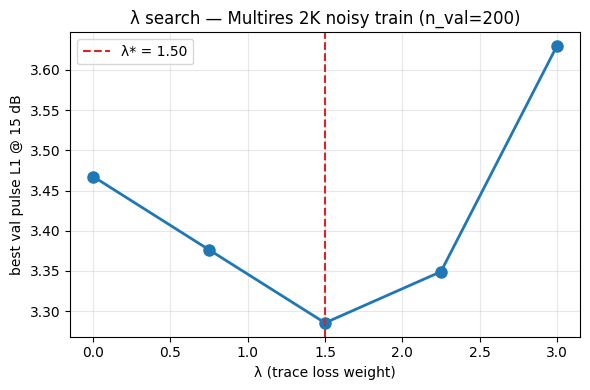

Per-λ summary:
  λ=0.0000  best_epoch= 36  stopped= 61  best_val_L1=3.46735
  λ=0.7500  best_epoch= 67  stopped= 92  best_val_L1=3.37621
  λ=1.5000  best_epoch=157  stopped=182  best_val_L1=3.28530
  λ=2.2500  best_epoch=183  stopped=200  best_val_L1=3.34904
  λ=3.0000  best_epoch= 59  stopped= 84  best_val_L1=3.62960


In [3]:
with open(META_JSON, encoding="utf-8") as f:
    run_log = json.load(f)

lambda_grid = np.array([e["lam"] for e in run_log], dtype=np.float64)
best_val = np.array([e["best_val_l1"] for e in run_log], dtype=np.float64)
best_epochs = np.array([e["best_epoch"] for e in run_log], dtype=np.int32)
lambda_opt = float(lambda_grid[int(np.argmin(best_val))])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lambda_grid, best_val, "o-", lw=2, ms=8)
ax.axvline(lambda_opt, color="C3", ls="--", lw=1.5, label=f"λ* = {lambda_opt:.2f}")
ax.set_xlabel("λ (trace loss weight)")
ax.set_ylabel(f"best val pulse L1 @ {VAL_SNR_DB:.0f} dB")
ax.set_title(f"λ search — Multires 2K noisy train (n_val={N_VAL})")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print("Per-λ summary:")
for e in run_log:
    print(
        f"  λ={e['lam']:.4f}  best_epoch={e['best_epoch']:3d}  "
        f"stopped={e['stopped_epoch']:3d}  best_val_L1={e['best_val_l1']:.5f}"
    )

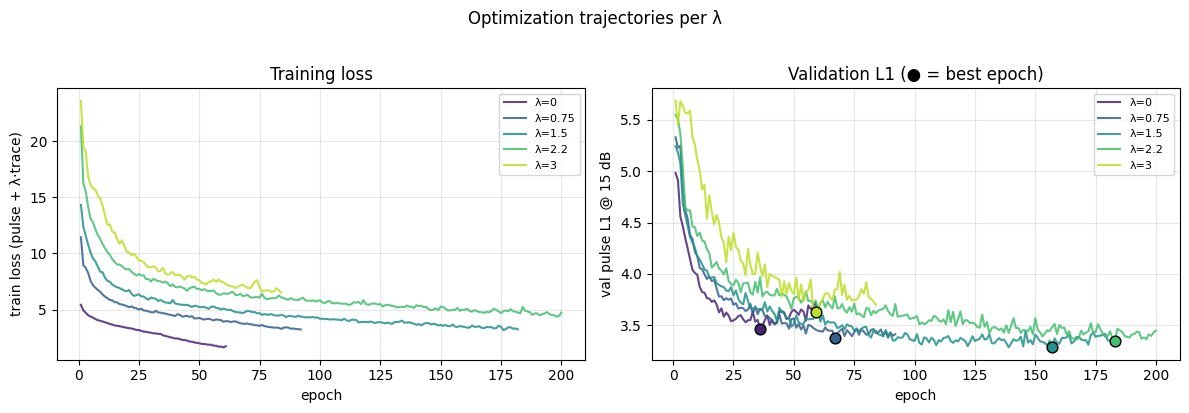

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(run_log)))

for e, c in zip(run_log, colors):
    lam = e["lam"]
    epochs = np.arange(1, len(e["val_l1_pulses"]) + 1)
    axes[0].plot(epochs, e["train_losses"], color=c, alpha=0.85, label=f"λ={lam:.2g}")
    axes[1].plot(epochs, e["val_l1_pulses"], color=c, alpha=0.85, label=f"λ={lam:.2g}")
    be = int(e["best_epoch"])
    axes[1].scatter([be], [e["val_l1_pulses"][be - 1]], color=c, s=60, edgecolors="k", zorder=5)

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("train loss (pulse + λ·trace)")
axes[0].set_title("Training loss")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel(f"val pulse L1 @ {VAL_SNR_DB:.0f} dB")
axes[1].set_title("Validation L1 (● = best epoch)")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle("Optimization trajectories per λ", y=1.02)
fig.tight_layout()
plt.show()

## 3. Baseline sweeps (60K / 2K without trace loss)

Load cached `.npz` sweeps if present; otherwise run from existing checkpoints.

In [5]:
from dataset_utils import PulseGridConfig, build_frog_dataloaders
from evaluate_cnn import run_cnn_snr_sweep, save_cnn_sweep
from train import build_model, load_checkpoint

MULTIRES_60K_CKPT = SRC / "checkpoints/large_60k_multires_50ep.pt"
MULTIRES_2K_CKPT = SRC / "checkpoints/large_2k_multires_50ep.pt"
RUN_BASELINE_SWEEPS = True  # set False to require pre-computed .npz only

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n = 64


def _ensure_sweep(ckpt_path, sweep_path, label):
    if sweep_path.exists():
        print(f"Using cached sweep: {sweep_path}")
        return load_cnn_sweep(sweep_path)
    if not RUN_BASELINE_SWEEPS:
        raise FileNotFoundError(f"Missing {sweep_path} and RUN_BASELINE_SWEEPS=False")
    if not ckpt_path.exists():
        raise FileNotFoundError(
            f"Missing checkpoint {ckpt_path}. "
            "Train with scripts/train_trace_to_pulse.py or copy from a prior run."
        )
    print(f"Running SNR sweep for {label} from {ckpt_path} …")
    bundle = build_frog_dataloaders(
        n_train=2048, n_val=512, n_test=N_TEST, batch_size=64, seed=SEED,
        device=device, grid=PulseGridConfig(n=n),
    )
    model, _ = load_checkpoint(ckpt_path, device=device)
    res = run_cnn_snr_sweep(model, bundle.test_loader, SNR_SWEEP_DB, experiment_name=label)
    save_cnn_sweep(sweep_path, res)
    print(f"Saved {sweep_path}")
    return res

sweep_60k = _ensure_sweep(MULTIRES_60K_CKPT, MULTIRES_60K_SWEEP, "Multires 60K")
sweep_2k = _ensure_sweep(MULTIRES_2K_CKPT, MULTIRES_2K_SWEEP, "Multires 2K (no trace loss)")

Using cached sweep: d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\large_60k_multires_50ep_cnn_sweep.npz
Using cached sweep: d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\large_2k_multires_50ep_cnn_sweep.npz


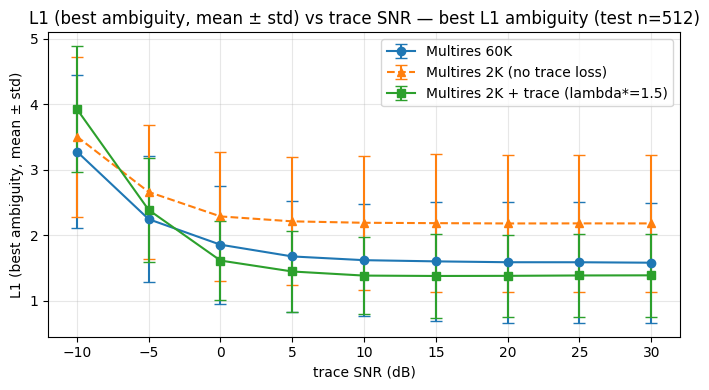

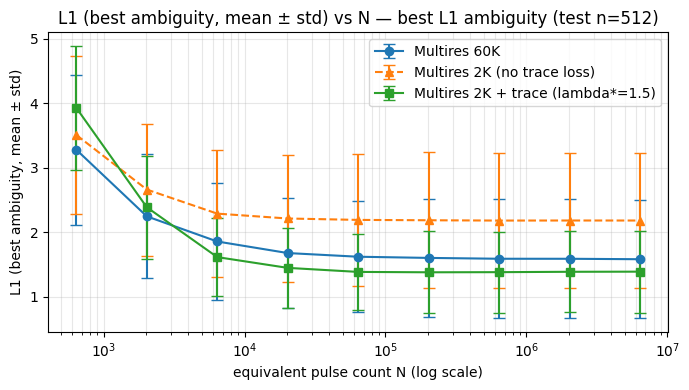

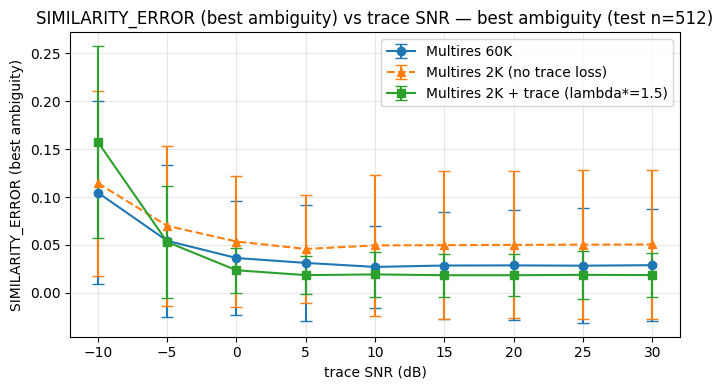

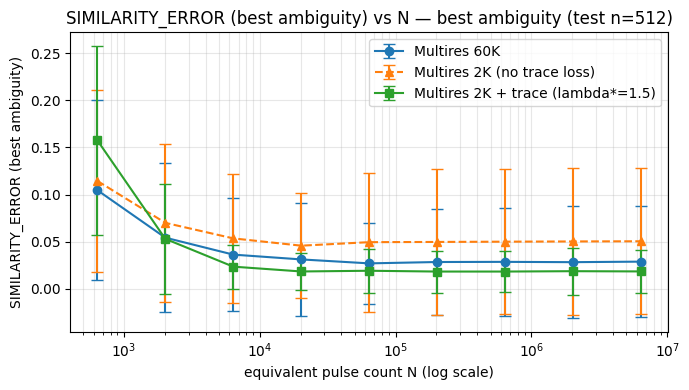

In [6]:
assert PHYS_SWEEP.exists(), f"Missing physical-model sweep: {PHYS_SWEEP} — run training cell first."

sweep_phys = load_cnn_sweep(PHYS_SWEEP)
sweep_phys.experiment_name = f"Multires 2K + trace (lambda*={lambda_opt:.2g})"
sweep_60k.experiment_name = "Multires 60K"
sweep_2k.experiment_name = "Multires 2K (no trace loss)"

curves = [sweep_60k, sweep_2k, sweep_phys]
snr = sweep_60k.snr_sweep_db
fmts = ["-o", "--^", "-s"]

def _plot_snr_metric(attr_m, attr_s, ylabel, title_suffix):
    series = [
        (getattr(r, attr_m), getattr(r, attr_s), fmts[i], r.experiment_name)
        for i, r in enumerate(curves)
    ]
    plot_metric_curves(
        snr, series,
        xlabel="trace SNR (dB)",
        ylabel=ylabel,
        title=f"{ylabel} vs trace SNR — {title_suffix} (test n={N_TEST})",
    )
    n_equiv = np.array([snr_db_to_equivalent_n_pulses(float(s)) for s in snr])
    plot_metric_curves(
        n_equiv, series,
        xlabel="equivalent pulse count N (log scale)",
        ylabel=ylabel,
        title=f"{ylabel} vs N — {title_suffix} (test n={N_TEST})",
        xscale="log",
    )

_plot_snr_metric(
    "cnn_l1_amb_m", "cnn_l1_amb_s",
    "L1 (best ambiguity, mean ± std)",
    "best L1 ambiguity",
)
_plot_snr_metric(
    "cnn_sim_amb_m", "cnn_sim_amb_s",
    "SIMILARITY_ERROR (best ambiguity)",
    "best ambiguity",
)

In [7]:
print(f"{'SNR (dB)':>10}  {'60K L1':>10}  {'2K L1':>10}  {'2K+trace L1':>12}  "
      f"{'60K sim':>10}  {'2K sim':>10}  {'2K+trace sim':>12}")
for i, s in enumerate(snr):
    print(
        f"{float(s):10.0f}  "
        f"{sweep_60k.cnn_l1_amb_m[i]:10.4f}  "
        f"{sweep_2k.cnn_l1_amb_m[i]:10.4f}  "
        f"{sweep_phys.cnn_l1_amb_m[i]:12.4f}  "
        f"{sweep_60k.cnn_sim_amb_m[i]:10.4f}  "
        f"{sweep_2k.cnn_sim_amb_m[i]:10.4f}  "
        f"{sweep_phys.cnn_sim_amb_m[i]:12.4f}"
    )

  SNR (dB)      60K L1       2K L1   2K+trace L1     60K sim      2K sim  2K+trace sim
       -10      3.2795      3.5089        3.9291      0.1047      0.1145        0.1575
        -5      2.2457      2.6616        2.3869      0.0544      0.0701        0.0531
         0      1.8554      2.2879        1.6132      0.0364      0.0536        0.0236
         5      1.6761      2.2124        1.4461      0.0313      0.0459        0.0185
        10      1.6190      2.1905        1.3834      0.0271      0.0496        0.0193
        15      1.6007      2.1850        1.3776      0.0285      0.0498        0.0184
        20      1.5876      2.1802        1.3795      0.0287      0.0501        0.0184
        25      1.5872      2.1813        1.3853      0.0284      0.0503        0.0188
        30      1.5804      2.1809        1.3874      0.0289      0.0505        0.0186


## 4. Example @ 5 dB — noisy trace + pulse reconstructions (3 models)

Separate **square** noisy trace (Energy [eV] vs τ [as]). Pulse panels: **Multires 60K**, **PCGPA**, **Multires 2K + trace loss** (λ*). Amplitude and phase on separate rows; L1 = best ambiguity.


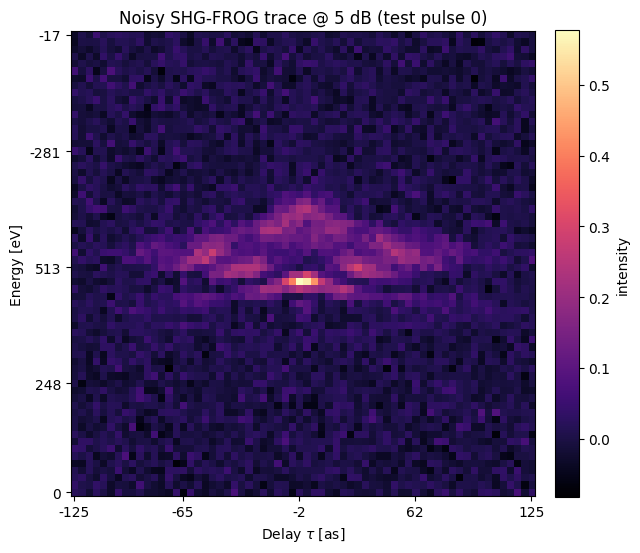

Multires 60K: L1 (best amb.) = 1.8415
Running PCGPA @ 5 dB (maxiter=200) …
PCGPA: L1 (best amb.) = 2.8016
Multires 2K + trace (lambda*=1.5): L1 (best amb.) = 1.1489


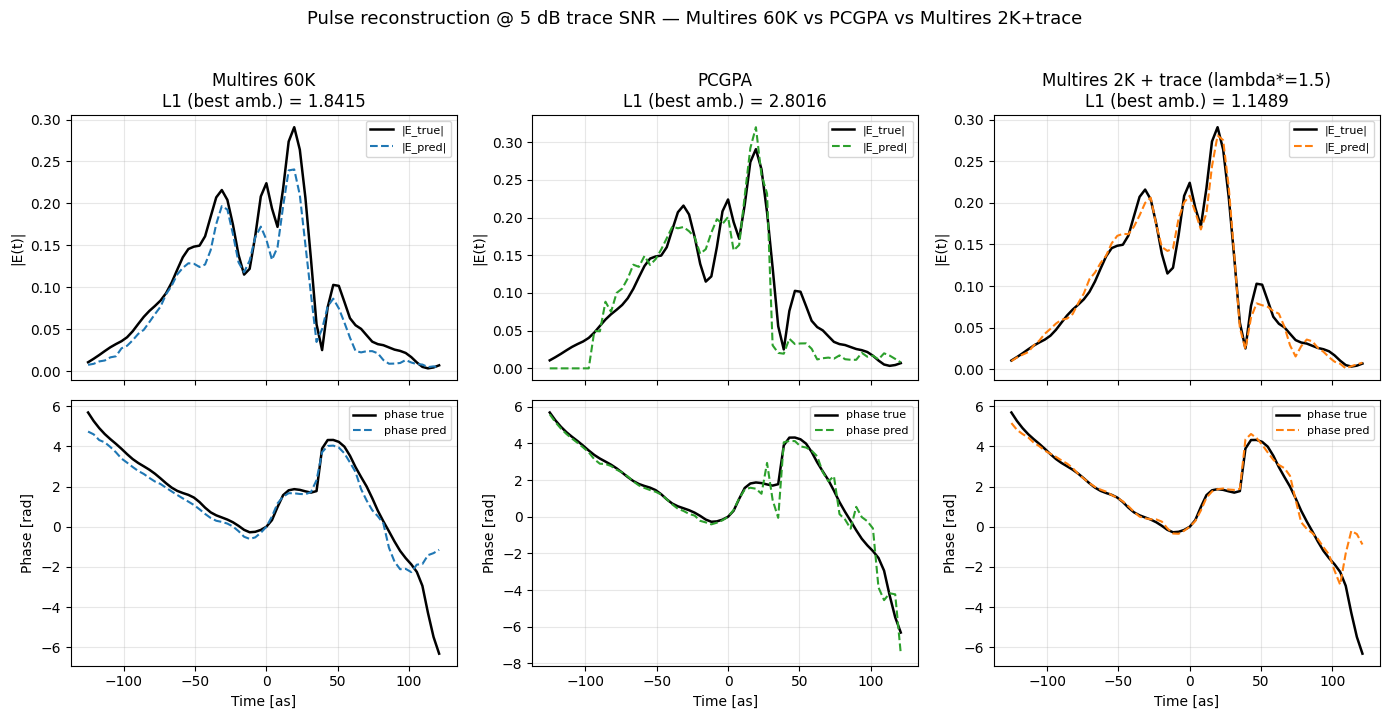

In [8]:
from pcgpa_reconstruct import reconstruct_pcgpa
from dataset_utils import PulseGridConfig, build_frog_dataloaders
from pulse_metrics import (
    best_l1_ambiguity,
    best_l1_ambiguity_field,
    packed_batch_to_complex,
    prepare_frog_trace_for_plot,
    unpack_packed_field,
    unwrap_phases_for_overlay,
)
from trace_noise import add_trace_noise_awgn
from train import build_model, load_checkpoint

ENERGY_SCALE_EV = 658.2  # omega [rad/as] -> Energy [eV], same as pulses_generator_NB.ipynb
PCGPA_MAXITER = 200
PCGPA_N_RESTARTS = 3

_PLOT_SNR_DB = 5.0
_plot_i = 0
_noise_seed = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n = 64
grid = PulseGridConfig(n=n)
DT = grid.dt
lam_opt = float(np.load(RESULTS_NPZ)["lambda_opt"])

bundle = build_frog_dataloaders(
    n_train=N_TRAIN,
    n_val=512,
    n_test=N_TEST,
    batch_size=64,
    seed=SEED,
    device=device,
    grid=grid,
)
I_test = bundle.test_loader.dataset.tensors[0]
E_test = bundle.test_loader.dataset.tensors[1]
t_vec = bundle.t_vec
w_vec = bundle.w_vec

I_clean_1 = I_test[_plot_i : _plot_i + 1].to(device)
torch.manual_seed(_noise_seed)
I_noisy = add_trace_noise_awgn(I_clean_1, _PLOT_SNR_DB)
i_noisy_np = I_noisy.squeeze(0).cpu().numpy()
e_true = unpack_packed_field(E_test[_plot_i].cpu().numpy())

_trace_plot, _tau_as, _omega_plot = prepare_frog_trace_for_plot(
    i_noisy_np, omega_axis=w_vec, dt=DT
)
_n_rows = _trace_plot.shape[0]
_tick_idx = np.linspace(0, _n_rows - 1, 5, dtype=int)
_omega_eV_plot = np.fft.fftshift(np.asarray(w_vec, dtype=float)) * ENERGY_SCALE_EV

# --- Figure 1: square noisy trace (64x64, separate plot) ---
fig_trace, ax_trace = plt.subplots(figsize=(6.5, 6.5))
im = ax_trace.imshow(_trace_plot, origin="lower", aspect="equal", cmap="magma")
ax_trace.set_xticks(_tick_idx)
ax_trace.set_xticklabels([f"{_tau_as[i]:.0f}" for i in _tick_idx])
ax_trace.set_yticks(_tick_idx)
ax_trace.set_yticklabels([f"{_omega_eV_plot[i]:.0f}" for i in _tick_idx])
ax_trace.set_title(f"Noisy SHG-FROG trace @ {_PLOT_SNR_DB:.0f} dB (test pulse {_plot_i})")
ax_trace.set_xlabel(r"Delay $\tau$ [as]")
ax_trace.set_ylabel("Energy [eV]")
fig_trace.colorbar(im, ax=ax_trace, fraction=0.046, pad=0.04, label="intensity")
fig_trace.tight_layout()
plt.show()

# --- Reconstructions: Multires 60K, PCGPA, Multires 2K + trace ---
_pred_colors = ["C0", "C2", "C1"]
_models = [
    ("Multires 60K", "cnn", SRC / "checkpoints/large_60k_multires_50ep.pt"),
    ("PCGPA", "pcgpa", None),
    (f"Multires 2K + trace (lambda*={lam_opt:.2g})", "cnn", OPT_CKPT),
]

_recs = []
for label, kind, ckpt_path in _models:
    if kind == "pcgpa":
        print(f"Running PCGPA @ {_PLOT_SNR_DB:.0f} dB (maxiter={PCGPA_MAXITER}) …")
        e_rec = reconstruct_pcgpa(
            i_noisy_np,
            dt=DT,
            maxiter=PCGPA_MAXITER,
            n_restarts=PCGPA_N_RESTARTS,
        )
    else:
        if ckpt_path == OPT_CKPT:
            ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
            model = build_model(n, device, model_name="multires")
            model.load_state_dict(ckpt["model_state_dict"])
        else:
            model, _ = load_checkpoint(ckpt_path, device=device)
        model.eval()
        with torch.no_grad():
            E_pred = model(I_noisy.unsqueeze(1))
        e_rec = packed_batch_to_complex(E_pred)[0]

    e_amb = best_l1_ambiguity_field(e_rec, e_true)
    l1 = best_l1_ambiguity(e_rec, e_true)
    ph_true, ph_rec = unwrap_phases_for_overlay(e_amb, e_true)
    _recs.append((label, e_amb, ph_true, ph_rec, l1))
    print(f"{label}: L1 (best amb.) = {l1:.4f}")

# --- Figure 2: amplitude (top) and phase (bottom), one column per model ---
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
ph_true_ref, _ = unwrap_phases_for_overlay(e_true, e_true)

for col, (color, (label, e_amb, ph_true, ph_rec, l1)) in enumerate(zip(_pred_colors, _recs)):
    ax_amp = axes[0, col]
    ax_amp.plot(t_vec, np.abs(e_true), "k-", lw=1.8, label="|E_true|")
    ax_amp.plot(t_vec, np.abs(e_amb), color=color, ls="--", lw=1.5, label="|E_pred|")
    ax_amp.set_ylabel("|E(t)|")
    ax_amp.set_title(f"{label}\nL1 (best amb.) = {l1:.4f}")
    ax_amp.legend(fontsize=8, loc="upper right")
    ax_amp.grid(True, alpha=0.3)

    ax_ph = axes[1, col]
    ax_ph.plot(t_vec, ph_true_ref, "k-", lw=1.8, label="phase true")
    ax_ph.plot(t_vec, ph_rec, color=color, ls="--", lw=1.5, label="phase pred")
    ax_ph.set_xlabel("Time [as]")
    ax_ph.set_ylabel("Phase [rad]")
    ax_ph.legend(fontsize=8, loc="upper right")
    ax_ph.grid(True, alpha=0.3)

fig.suptitle(
    f"Pulse reconstruction @ {_PLOT_SNR_DB:.0f} dB trace SNR — "
    "Multires 60K vs PCGPA vs Multires 2K+trace",
    y=1.02,
    fontsize=13,
)
fig.tight_layout()
plt.show()


## 5. Example @ 0 dB — noisy trace + pulse reconstructions (3 models)

Same code as section 4, with _PLOT_SNR_DB = 0.0. Section 4 (5 dB) stays above.

Separate **square** noisy trace (Energy [eV] vs tau [as]). Pulse panels: **Multires 60K**, **PCGPA**, **Multires 2K + trace loss** (lambda*).


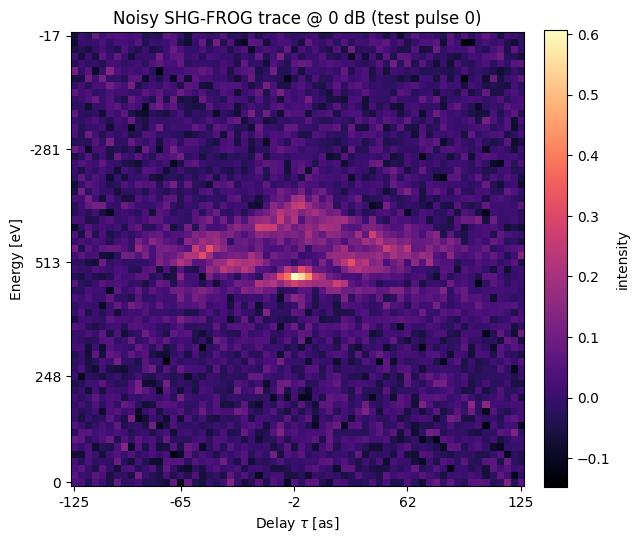

Multires 60K: L1 (best amb.) = 1.5994
Running PCGPA @ 0 dB (maxiter=200) …
PCGPA: L1 (best amb.) = 3.5999
Multires 2K + trace (lambda*=1.5): L1 (best amb.) = 1.2964


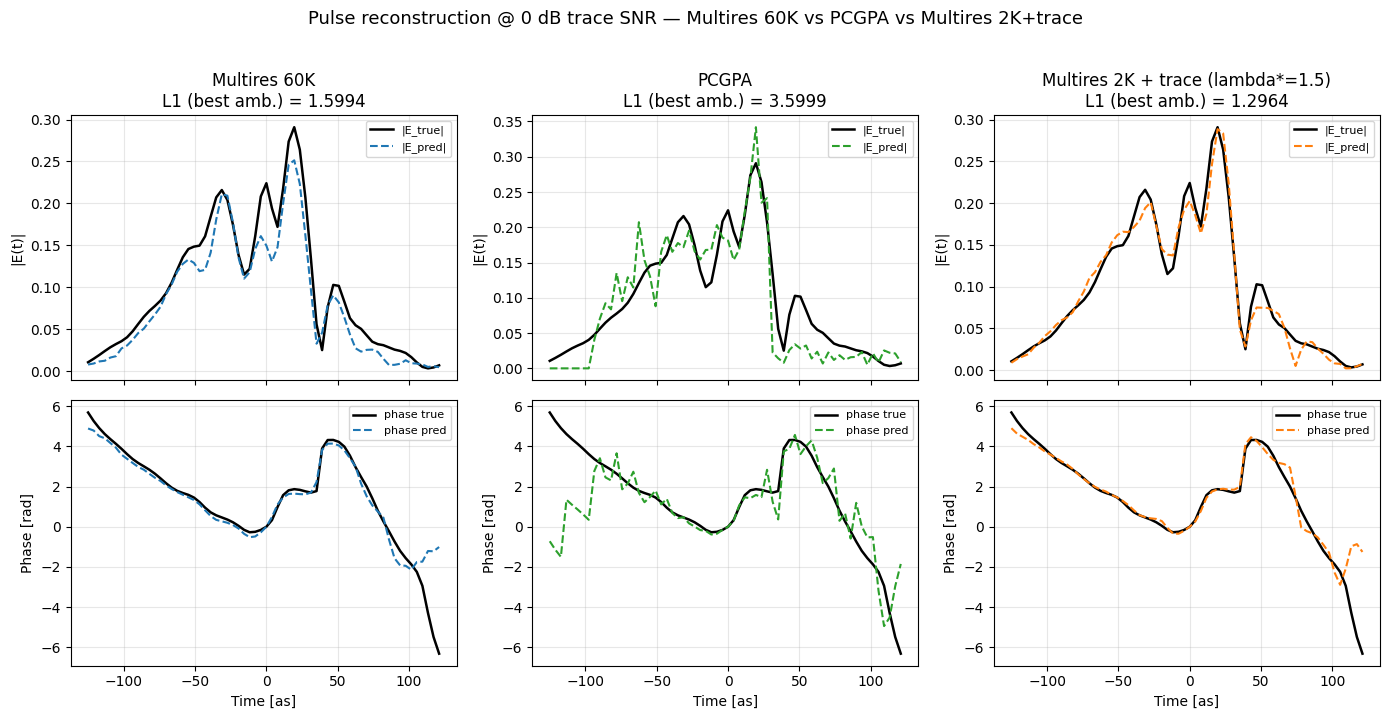

In [4]:
from pcgpa_reconstruct import reconstruct_pcgpa
from dataset_utils import PulseGridConfig, build_frog_dataloaders
from pulse_metrics import (
    best_l1_ambiguity,
    best_l1_ambiguity_field,
    packed_batch_to_complex,
    prepare_frog_trace_for_plot,
    unpack_packed_field,
    unwrap_phases_for_overlay,
)
from trace_noise import add_trace_noise_awgn
from train import build_model, load_checkpoint

ENERGY_SCALE_EV = 658.2  # omega [rad/as] -> Energy [eV], same as pulses_generator_NB.ipynb
PCGPA_MAXITER = 200
PCGPA_N_RESTARTS = 3

_PLOT_SNR_DB = 0.0
_plot_i = 0
_noise_seed = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n = 64
grid = PulseGridConfig(n=n)
DT = grid.dt
lam_opt = float(np.load(RESULTS_NPZ)["lambda_opt"])

bundle = build_frog_dataloaders(
    n_train=N_TRAIN,
    n_val=512,
    n_test=N_TEST,
    batch_size=64,
    seed=SEED,
    device=device,
    grid=grid,
)
I_test = bundle.test_loader.dataset.tensors[0]
E_test = bundle.test_loader.dataset.tensors[1]
t_vec = bundle.t_vec
w_vec = bundle.w_vec

I_clean_1 = I_test[_plot_i : _plot_i + 1].to(device)
torch.manual_seed(_noise_seed)
I_noisy = add_trace_noise_awgn(I_clean_1, _PLOT_SNR_DB)
i_noisy_np = I_noisy.squeeze(0).cpu().numpy()
e_true = unpack_packed_field(E_test[_plot_i].cpu().numpy())

_trace_plot, _tau_as, _omega_plot = prepare_frog_trace_for_plot(
    i_noisy_np, omega_axis=w_vec, dt=DT
)
_n_rows = _trace_plot.shape[0]
_tick_idx = np.linspace(0, _n_rows - 1, 5, dtype=int)
_omega_eV_plot = np.fft.fftshift(np.asarray(w_vec, dtype=float)) * ENERGY_SCALE_EV

# --- Figure 1: square noisy trace (64x64, separate plot) ---
fig_trace, ax_trace = plt.subplots(figsize=(6.5, 6.5))
im = ax_trace.imshow(_trace_plot, origin="lower", aspect="equal", cmap="magma")
ax_trace.set_xticks(_tick_idx)
ax_trace.set_xticklabels([f"{_tau_as[i]:.0f}" for i in _tick_idx])
ax_trace.set_yticks(_tick_idx)
ax_trace.set_yticklabels([f"{_omega_eV_plot[i]:.0f}" for i in _tick_idx])
ax_trace.set_title(f"Noisy SHG-FROG trace @ {_PLOT_SNR_DB:.0f} dB (test pulse {_plot_i})")
ax_trace.set_xlabel(r"Delay $\tau$ [as]")
ax_trace.set_ylabel("Energy [eV]")
fig_trace.colorbar(im, ax=ax_trace, fraction=0.046, pad=0.04, label="intensity")
fig_trace.tight_layout()
plt.show()

# --- Reconstructions: Multires 60K, PCGPA, Multires 2K + trace ---
_pred_colors = ["C0", "C2", "C1"]
_models = [
    ("Multires 60K", "cnn", SRC / "checkpoints/large_60k_multires_50ep.pt"),
    ("PCGPA", "pcgpa", None),
    (f"Multires 2K + trace (lambda*={lam_opt:.2g})", "cnn", OPT_CKPT),
]

_recs = []
for label, kind, ckpt_path in _models:
    if kind == "pcgpa":
        print(f"Running PCGPA @ {_PLOT_SNR_DB:.0f} dB (maxiter={PCGPA_MAXITER}) …")
        e_rec = reconstruct_pcgpa(
            i_noisy_np,
            dt=DT,
            maxiter=PCGPA_MAXITER,
            n_restarts=PCGPA_N_RESTARTS,
        )
    else:
        if ckpt_path == OPT_CKPT:
            ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
            model = build_model(n, device, model_name="multires")
            model.load_state_dict(ckpt["model_state_dict"])
        else:
            model, _ = load_checkpoint(ckpt_path, device=device)
        model.eval()
        with torch.no_grad():
            E_pred = model(I_noisy.unsqueeze(1))
        e_rec = packed_batch_to_complex(E_pred)[0]

    e_amb = best_l1_ambiguity_field(e_rec, e_true)
    l1 = best_l1_ambiguity(e_rec, e_true)
    ph_true, ph_rec = unwrap_phases_for_overlay(e_amb, e_true)
    _recs.append((label, e_amb, ph_true, ph_rec, l1))
    print(f"{label}: L1 (best amb.) = {l1:.4f}")

# --- Figure 2: amplitude (top) and phase (bottom), one column per model ---
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
ph_true_ref, _ = unwrap_phases_for_overlay(e_true, e_true)

for col, (color, (label, e_amb, ph_true, ph_rec, l1)) in enumerate(zip(_pred_colors, _recs)):
    ax_amp = axes[0, col]
    ax_amp.plot(t_vec, np.abs(e_true), "k-", lw=1.8, label="|E_true|")
    ax_amp.plot(t_vec, np.abs(e_amb), color=color, ls="--", lw=1.5, label="|E_pred|")
    ax_amp.set_ylabel("|E(t)|")
    ax_amp.set_title(f"{label}\nL1 (best amb.) = {l1:.4f}")
    ax_amp.legend(fontsize=8, loc="upper right")
    ax_amp.grid(True, alpha=0.3)

    ax_ph = axes[1, col]
    ax_ph.plot(t_vec, ph_true_ref, "k-", lw=1.8, label="phase true")
    ax_ph.plot(t_vec, ph_rec, color=color, ls="--", lw=1.5, label="phase pred")
    ax_ph.set_xlabel("Time [as]")
    ax_ph.set_ylabel("Phase [rad]")
    ax_ph.legend(fontsize=8, loc="upper right")
    ax_ph.grid(True, alpha=0.3)

fig.suptitle(
    f"Pulse reconstruction @ {_PLOT_SNR_DB:.0f} dB trace SNR — "
    "Multires 60K vs PCGPA vs Multires 2K+trace",
    y=1.02,
    fontsize=13,
)
fig.tight_layout()
plt.show()
